In [2]:
import random
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# 固定随机种子，尽量保证每次运行结果一致
random.seed(42)
torch.manual_seed(42)

# 自动选择运行设备
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch版本：", torch.__version__)
print("运行设备：", device)

PyTorch版本： 2.6.0
运行设备： cpu


In [1]:
sentences = [
    "我 喜欢 吃 苹果",
    "我 喜欢 吃 香蕉",
    "他 喜欢 吃 苹果",
    "她 喜欢 吃 香蕉",
    "苹果 是 一种 水果",
    "香蕉 是 一种 水果",
    "橘子 是 一种 水果",
    "苹果 香蕉 都 是 水果",
    "猫 喜欢 吃 鱼",
    "狗 喜欢 吃 肉",
    "猫 是 动物",
    "狗 是 动物",
]

# 因为句子中的词已经使用空格分开，所以直接使用 split 分词
tokenized_sentences = [sentence.split() for sentence in sentences]

for sentence in tokenized_sentences:
    print(sentence)


['我', '喜欢', '吃', '苹果']
['我', '喜欢', '吃', '香蕉']
['他', '喜欢', '吃', '苹果']
['她', '喜欢', '吃', '香蕉']
['苹果', '是', '一种', '水果']
['香蕉', '是', '一种', '水果']
['橘子', '是', '一种', '水果']
['苹果', '香蕉', '都', '是', '水果']
['猫', '喜欢', '吃', '鱼']
['狗', '喜欢', '吃', '肉']
['猫', '是', '动物']
['狗', '是', '动物']


In [3]:
# 收集语料中出现的所有词
vocabulary = sorted({
    word
    for sentence in tokenized_sentences
    for word in sentence
})

# 建立“词语 → 编号”和“编号 → 词语”的映射
word_to_index = {
    word: index
    for index, word in enumerate(vocabulary)
}

index_to_word = {
    index: word
    for word, index in word_to_index.items()
}

vocab_size = len(vocabulary)

print("词表大小：", vocab_size)
print("词表：", vocabulary)
print("词语到编号：", word_to_index)

词表大小： 17
词表： ['一种', '他', '动物', '吃', '喜欢', '她', '我', '是', '橘子', '水果', '狗', '猫', '肉', '苹果', '都', '香蕉', '鱼']
词语到编号： {'一种': 0, '他': 1, '动物': 2, '吃': 3, '喜欢': 4, '她': 5, '我': 6, '是': 7, '橘子': 8, '水果': 9, '狗': 10, '猫': 11, '肉': 12, '苹果': 13, '都': 14, '香蕉': 15, '鱼': 16}


In [4]:
window_size = 2

In [5]:
def create_skipgram_pairs(sentences, word_to_index, window_size=2):
    center_words = []
    context_words = []

    for sentence in sentences:
        sentence_ids = [
            word_to_index[word]
            for word in sentence
        ]

        for center_position, center_id in enumerate(sentence_ids):
            left = max(0, center_position - window_size)
            right = min(
                len(sentence_ids),
                center_position + window_size + 1
            )

            for context_position in range(left, right):
                # 中心词不能预测自己
                if context_position == center_position:
                    continue

                context_id = sentence_ids[context_position]

                center_words.append(center_id)
                context_words.append(context_id)

    return (
        torch.tensor(center_words, dtype=torch.long),
        torch.tensor(context_words, dtype=torch.long),
    )


center_ids, context_ids = create_skipgram_pairs(
    tokenized_sentences,
    word_to_index,
    window_size=window_size,
)

print("训练样本数量：", len(center_ids))

训练样本数量： 116


In [6]:
for center_id, context_id in zip(center_ids[:20], context_ids[:20]):
    center_word = index_to_word[center_id.item()]
    context_word = index_to_word[context_id.item()]

    print(f"{center_word} -> {context_word}")

我 -> 喜欢
我 -> 吃
喜欢 -> 我
喜欢 -> 吃
喜欢 -> 苹果
吃 -> 我
吃 -> 喜欢
吃 -> 苹果
苹果 -> 喜欢
苹果 -> 吃
我 -> 喜欢
我 -> 吃
喜欢 -> 我
喜欢 -> 吃
喜欢 -> 香蕉
吃 -> 我
吃 -> 喜欢
吃 -> 香蕉
香蕉 -> 喜欢
香蕉 -> 吃


In [7]:
dataset = TensorDataset(center_ids, context_ids)

data_loader = DataLoader(
    dataset,
    batch_size=16,
    shuffle=True,
)

batch_center, batch_context = next(iter(data_loader))

print("中心词编号形状：", batch_center.shape)
print("上下文词编号形状：", batch_context.shape)
print("一批中心词编号：", batch_center)

中心词编号形状： torch.Size([16])
上下文词编号形状： torch.Size([16])
一批中心词编号： tensor([16, 10,  7,  7,  6,  4,  9,  4,  0,  4, 13, 13, 10,  0,  5,  2])


In [8]:
class SkipGramModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim):
        super().__init__()

        # 输入Embedding矩阵
        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
        )

        # 根据中心词向量预测词表中所有上下文词
        self.output_layer = nn.Linear(
            in_features=embedding_dim,
            out_features=vocab_size,
            bias=False,
        )

    def forward(self, center_word_ids):
        # [batch_size]
        #      ↓
        # [batch_size, embedding_dim]
        word_vectors = self.embedding(center_word_ids)

        # [batch_size, embedding_dim]
        #      ↓
        # [batch_size, vocab_size]
        logits = self.output_layer(word_vectors)

        return logits

In [9]:
embedding_dim = 16

model = SkipGramModel(
    vocab_size=vocab_size,
    embedding_dim=embedding_dim,
).to(device)

print(model)

SkipGramModel(
  (embedding): Embedding(17, 16)
  (output_layer): Linear(in_features=16, out_features=17, bias=False)
)


In [11]:
batch_center = batch_center.to(device)

logits = model(batch_center)

print("输入形状：", batch_center.shape)
print("Embedding矩阵形状：", model.embedding.weight.shape)
print("模型输出形状：", logits.shape)

输入形状： torch.Size([16])
Embedding矩阵形状： torch.Size([17, 16])
模型输出形状： torch.Size([16, 17])


In [12]:
loss_function = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.01,
)

num_epochs = 500
loss_history = []

for epoch in range(1, num_epochs + 1):
    model.train()

    total_loss = 0.0

    for batch_center, batch_context in data_loader:
        batch_center = batch_center.to(device)
        batch_context = batch_context.to(device)

        # 1. 清空上一轮保存的梯度
        optimizer.zero_grad()

        # 2. 根据中心词预测上下文词
        logits = model(batch_center)

        # 3. 计算预测结果与真实上下文词之间的损失
        loss = loss_function(logits, batch_context)

        # 4. 反向传播，计算梯度
        loss.backward()

        # 5. 根据梯度更新模型参数
        optimizer.step()

        total_loss += loss.item()

    average_loss = total_loss / len(data_loader)
    loss_history.append(average_loss)

    if epoch == 1 or epoch % 50 == 0:
        print(
            f"Epoch {epoch:3d}/{num_epochs}, "
            f"Loss: {average_loss:.4f}"
        )

Epoch   1/500, Loss: 2.8123
Epoch  50/500, Loss: 1.6855
Epoch 100/500, Loss: 1.6494
Epoch 150/500, Loss: 1.6696
Epoch 200/500, Loss: 1.6573
Epoch 250/500, Loss: 1.7159
Epoch 300/500, Loss: 1.7106
Epoch 350/500, Loss: 1.6672
Epoch 400/500, Loss: 1.6671
Epoch 450/500, Loss: 1.6533
Epoch 500/500, Loss: 1.6334


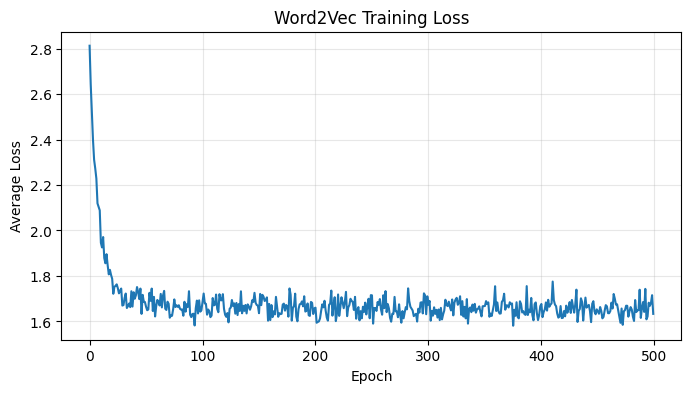

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(loss_history)

plt.xlabel("Epoch")
plt.ylabel("Average Loss")
plt.title("Word2Vec Training Loss")
plt.grid(alpha=0.3)

plt.show()

In [21]:
import sys
import subprocess

subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "matplotlib",
])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 136.8 kB/s  0:01:08m0:00:0100:03
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 176.3 kB/s  0:00:27 eta 0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 114.7 kB/s  0:00:13 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


0

In [14]:
model.eval()

with torch.no_grad():
    word_vectors = model.embedding.weight.detach().cpu()

print("词向量矩阵形状：", word_vectors.shape)

词向量矩阵形状： torch.Size([17, 16])


In [15]:
def cosine_similarity(word1, word2, word_vectors, word_to_index):
    vector1 = word_vectors[word_to_index[word1]]
    vector2 = word_vectors[word_to_index[word2]]

    similarity = torch.nn.functional.cosine_similarity(
        vector1.unsqueeze(0),
        vector2.unsqueeze(0),
    )

    return similarity.item()

In [16]:
word_pairs = [
    ("苹果", "香蕉"),
    ("猫", "狗"),
    ("苹果", "猫"),
    ("水果", "香蕉"),
]

for word1, word2 in word_pairs:
    score = cosine_similarity(
        word1,
        word2,
        word_vectors,
        word_to_index,
    )

    print(f"{word1} 与 {word2} 的相似度：{score:.4f}")

苹果 与 香蕉 的相似度：0.2781
猫 与 狗 的相似度：0.5730
苹果 与 猫 的相似度：0.2702
水果 与 香蕉 的相似度：0.2629


In [17]:
def find_similar_words(
    query_word,
    word_vectors,
    word_to_index,
    index_to_word,
    top_k=5,
):
    if query_word not in word_to_index:
        raise ValueError(f"词表中不存在：{query_word}")

    query_id = word_to_index[query_word]
    query_vector = word_vectors[query_id]

    # 对每个词向量进行归一化
    normalized_vectors = torch.nn.functional.normalize(
        word_vectors,
        p=2,
        dim=1,
    )

    normalized_query = torch.nn.functional.normalize(
        query_vector.unsqueeze(0),
        p=2,
        dim=1,
    )

    # 计算查询词与所有词的余弦相似度
    similarities = torch.matmul(
        normalized_vectors,
        normalized_query.squeeze(0),
    )

    # 排除查询词本身
    similarities[query_id] = float("-inf")

    top_k = min(top_k, len(word_to_index) - 1)
    values, indices = torch.topk(similarities, k=top_k)

    results = []

    for score, index in zip(values, indices):
        results.append(
            (index_to_word[index.item()], score.item())
        )

    return results

In [18]:
for query_word in ["苹果", "猫", "水果"]:
    print(f"\n与“{query_word}”相似的词：")

    results = find_similar_words(
        query_word,
        word_vectors,
        word_to_index,
        index_to_word,
        top_k=5,
    )

    for similar_word, score in results:
        print(f"  {similar_word}: {score:.4f}")


与“苹果”相似的词：
  狗: 0.4851
  她: 0.3440
  我: 0.3260
  橘子: 0.2800
  香蕉: 0.2781

与“猫”相似的词：
  狗: 0.5730
  鱼: 0.4972
  我: 0.4368
  他: 0.3524
  苹果: 0.2702

与“水果”相似的词：
  橘子: 0.7342
  香蕉: 0.2629
  苹果: 0.2478
  狗: 0.1928
  一种: 0.1095


In [19]:
# 将所有词向量移动到中心位置
centered_vectors = word_vectors - word_vectors.mean(
    dim=0,
    keepdim=True,
)

# 使用PCA降到二维
_, _, principal_directions = torch.pca_lowrank(
    centered_vectors,
    q=2,
)

coordinates = torch.matmul(
    centered_vectors,
    principal_directions[:, :2],
)

print("降维后的形状：", coordinates.shape)

降维后的形状： torch.Size([17, 2])


/home/asus/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 19968 (\N{CJK UNIFIED IDEOGRAPH-4E00}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asus/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 31181 (\N{CJK UNIFIED IDEOGRAPH-79CD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asus/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20182 (\N{CJK UNIFIED IDEOGRAPH-4ED6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asus/miniconda3/envs/pytorch_env/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21160 (\N{CJK UNIFIED IDEOGRAPH-52A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/asus/miniconda3/envs/pytorch_env/lib/python3.10/site-packa

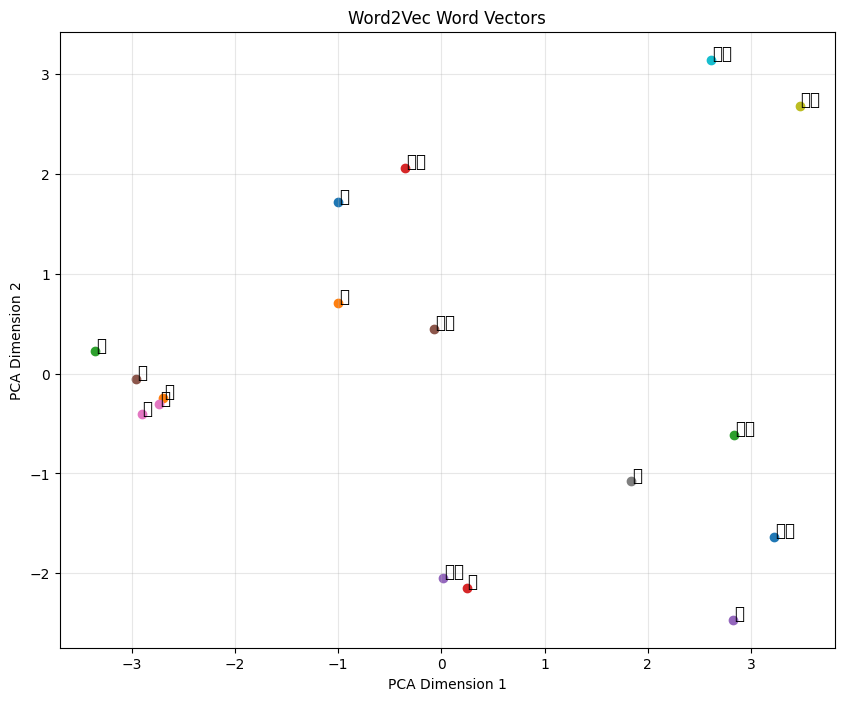

In [23]:
plt.figure(figsize=(10, 8))

for index in range(vocab_size):
    x = coordinates[index, 0].item()
    y = coordinates[index, 1].item()
    word = index_to_word[index]

    plt.scatter(x, y)
    plt.text(x + 0.01, y + 0.01, word, fontsize=12)

plt.title("Word2Vec Word Vectors")
plt.xlabel("PCA Dimension 1")
plt.ylabel("PCA Dimension 2")
plt.grid(alpha=0.3)

plt.show()